<a href="https://colab.research.google.com/github/TeraneAgaeva/python_for_ds_tasks/blob/main/Agaeva_%22HW_2_2_%D0%9C%D0%B0%D1%82%D0%B5%D0%BC%D0%B0%D1%82%D0%B8%D1%87%D0%BD%D0%B5_%D1%84%D0%BE%D1%80%D0%BC%D1%83%D0%BB%D1%8E%D0%B2%D0%B0%D0%BD%D0%BD%D1%8F_%D0%BB%D0%BE%D0%B3%D1%96%D1%81%D1%82%D0%B8%D1%87%D0%BD%D0%BE%D1%97_%D1%80%D0%B5%D0%B3%D1%80%D0%B5%D1%81%D1%96%D1%97_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В цьому домашньому завданні ми реалізуємо логістичну регресію на `numpy`.
Ці завдання допоможуть вам ґрунтовно засвоїти основні концепції логістичної регресії та реалізувати їх на практиці 🔥

#### Завдання 1: Реалізація функції сигмоїди
1. З використанням `numpy` напишіть функцію `sigmoid(z)` для обчислення значення сигмоїди згідно з формулою:
   $$
   \sigma(z) = \frac{1}{1 + e^{-z}}
   $$
2. Використовуючи цю функцію, обчисліть значення сигмоїди для наступних даних: $ z = [-2, -1, 0, 1, 2] $. Виведіть результат обчислень.


In [1]:
pip install --upgrade scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 52.2 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


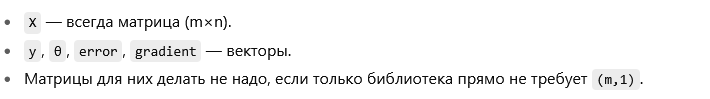

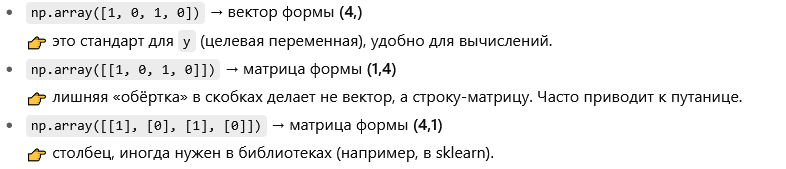

In [2]:
import sklearn
print(sklearn.__version__)
print(sklearn.__file__) # Это покажет, откуда загружен пакет

1.7.2
/usr/local/lib/python3.12/dist-packages/sklearn/__init__.py


In [3]:
import numpy as np
import pandas as pd

In [4]:
z=[-2,-1,0,1,2]

**1. Рішення:**

In [34]:
def sigmoid(z):
  return 1/(1+np.exp(-z))
print(sigmoid)

<function sigmoid at 0x7eded7beaca0>


**2. Рішення:**

In [35]:
z = np.array(z, dtype=float)
print(sigmoid(z))

[0.11920292 0.26894142 0.5        0.73105858 0.88079708]




#### Завдання 2: Реалізація функції гіпотези для логістичної регресії
1. Напишіть функцію `hypothesis(theta, X)`, яка обчислює гіпотезу для логістичної регресії, використовуючи функцію сигмоїди. Формула гіпотези:
   $$
   h_\theta(x) = \sigma(\theta^T x) = \frac{1}{1 + e^{-\theta^T x}}
   $$
2. Використайте функцію `hypothesis` для обчислення значень гіпотези для наступних даних:
   
   $\theta = [0.5, -0.5]$
   
   $X = \begin{bmatrix} 1 & 2 \\ 1 & -1 \\ 1 & 0 \\ 1 & 1 \end{bmatrix}$

  Виведіть результат обчислень.


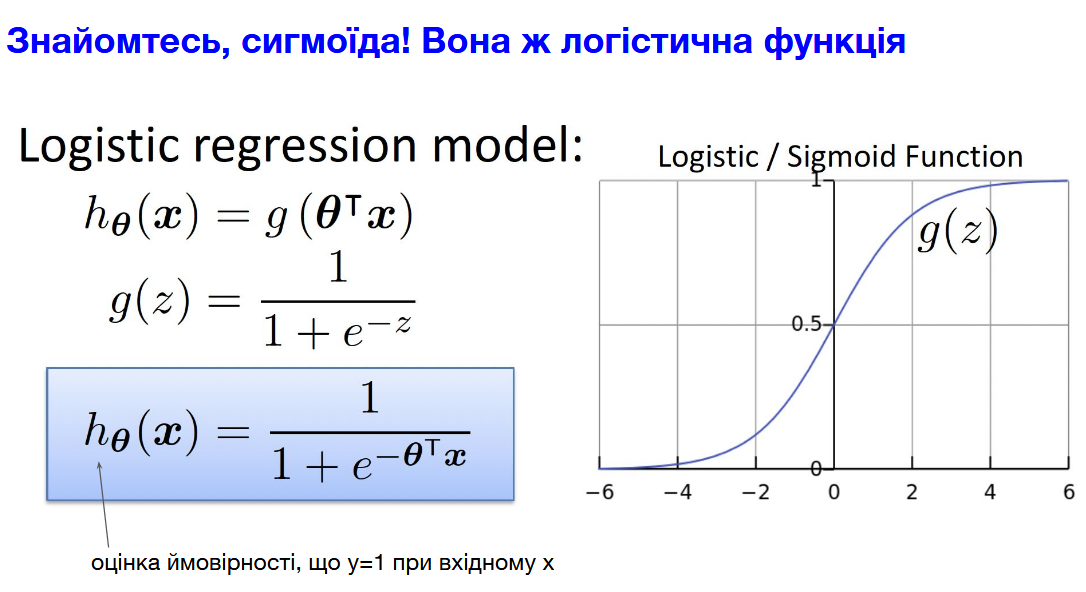
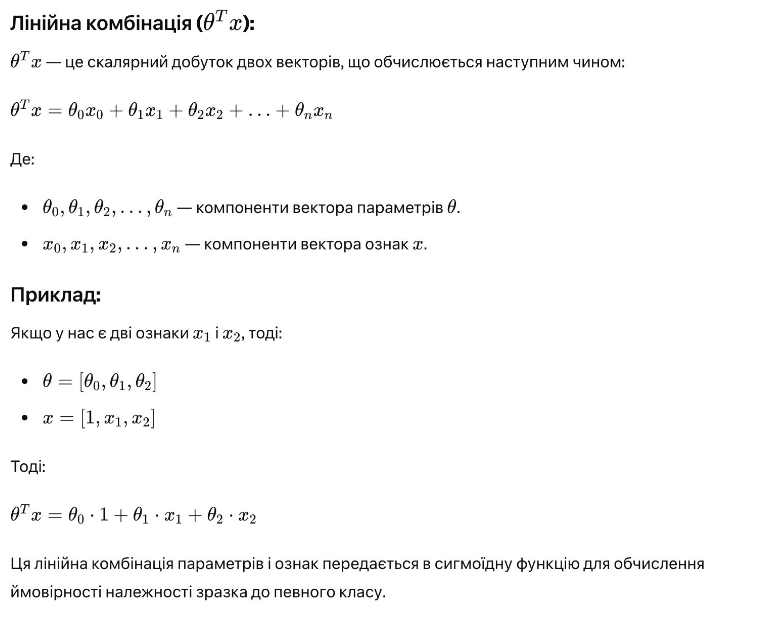

In [7]:
theta = np.array([0.5, -0.5])

In [8]:
X = np.array([[1, 2],
[1, -1],
[1, 0],
[1, 1]])

**1. Рішення:**

In [9]:
def hypothesis(theta, X): #  Функція обчислює ймовірність
  return  1 / (1 + np.exp(-np.dot(theta, X.T)))
  print(hypothesis)

**2. Рішення:**

In [10]:
print(hypothesis(theta, X))

[0.37754067 0.73105858 0.62245933 0.5       ]


Правило матричного умножения

Матричное умножение (оператор @ или функция np.dot()) возможно только тогда, когда количество столбцов в первой матрице равно количеству строк во второй матрице.


  Матрица A имеет размер (m х **k**).

  Матрица B имеет размер (**k** х  n).

  
  Результат A @ B будет иметь размер (**m** × **n**).

#### Завдання 3: Реалізація функції для підрахунку градієнтів фукнції втрат
1. Напишіть функцію `compute_gradient(theta, X, y)`, яка обчислює градієнти функції втрат для логістичної регресії. Формула для обчислення градієнта:
   $$
   \frac{\partial L(\theta)}{\partial \theta_j} = \frac{1}{m} \sum_{i=1}^{m} \left[ (h_\theta(x^{(i)}) - y^{(i)}) x_j^{(i)} \right]
   $$
2. Використайте функцію `compute_gradient` для обчислення градієнтів для наступних даних:

  $\theta = [0.5, -0.5]$

  $X = \begin{bmatrix} 1 & 2 \\ 1 & -1 \\ 1 & 0 \\ 1 & 1 \end{bmatrix}$

  $y = [1, 0, 1, 0]$

  Виведіть результат обчислень.

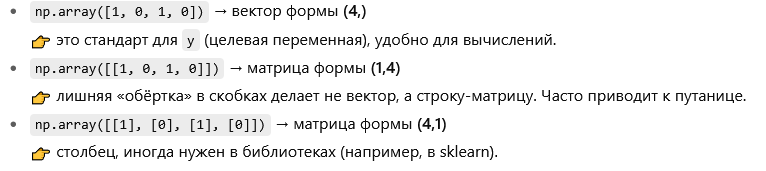

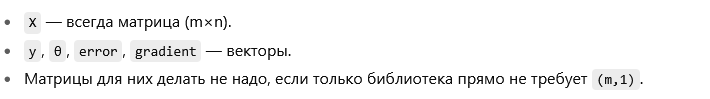

In [11]:
y = np.array([1, 0, 1, 0])

In [12]:
def compute_gradient(theta, X, y):
    m = len(y)
    error = hypothesis(theta, X) - y
    gradient = np.dot(error, X) / m
    return gradient

In [13]:
compute_gradient(theta, X, y)

array([ 0.05776464, -0.36899431])


#### Завдання 4: Реалізація повного батч градієнтного спуску

**Задача:**
1. Напишіть функцію `full_batch_gradient_descent(X, y, lr=0.1, epochs=100)`, яка реалізує алгоритм Full градієнтного спуску для логістичної регресії. Використовуйте такі формули:
   - Гіпотеза: $ h_\theta(x) = \sigma(\theta^T x) $
   - Оновлення параметрів: $ \theta_j := \theta_j - \alpha \frac{\partial L(\theta)}{\partial \theta_j} $
2. Використайте функцію `full_batch_gradient_descent` для обчислення параметрів моделі на наступних даних:

  $X = \begin{bmatrix} 1 & 2 \\ 1 & -1 \\ 1 & 0 \\ 1 & 1 \end{bmatrix}$

  $y = [1, 0, 1, 0]$

  Увага! Матриця $X$ вже має стовпець одиниць і передбачається, що це. - стовпець для intercept - параметра зсуву.

  Виведіть результат обчислень.


Формула для обчислення градієнта:
   $$
   \frac{\partial L(\theta)}{\partial \theta_j} = \frac{1}{m} \sum_{i=1}^{m} \left[ (h_\theta(x^{(i)}) - y^{(i)}) x_j^{(i)} \right]
   $$
   - Гіпотеза: $ h_\theta(x) = \sigma(\theta^T x) $
   - Оновлення параметрів: $ \theta_j := \theta_j - \alpha \frac{\partial L(\theta)}{\partial \theta_j} $

In [27]:
# повторили розрахунок градієнта(був у попередньому завданні)
def compute_gradient(theta, X, y):
    m = len(y)
    error = hypothesis(theta, X) - y
    gradient = np.dot(error, X) / m
    return gradient
errors = []

# Основная функция для градиентного спуска
def full_batch_gradient_descent(X, y, lr=0.1, epochs=100):
    # Инициализируем theta нулями. Количество параметров равно количеству столбцов в X.
    theta = np.zeros(X.shape[1])
    m = len(y)


    # Запускаем цикл на заданное количество эпох
    for _ in range(epochs):
        # Вычисляем градиент
        gradient = compute_gradient(theta, X, y)

        # Обновляем параметры theta
        theta = theta - lr * gradient
# Обчислення функції втрат для кожної ітерації
        h = hypothesis(theta, X)
        loss = (-1/m) * np.sum(y * np.log(h) + (1 - y) * np.log(1 - h))
        errors.append(loss)

    return theta, errors



# Виклик функції та результат
print(full_batch_gradient_descent(X, y))
theta_learned, errors_list = full_batch_gradient_descent(X, y) #Навчені параметри моделі
print(f"Навчені параметри моделі theta_learned та значення функції втрат errors: {theta_learned, errors_list}")


(array([-0.2893693 ,  0.77655125]), [np.float64(0.6870143589060703), np.float64(0.6813308202031507), np.float64(0.6760595903938247), np.float64(0.671166642736349), np.float64(0.6666207373973663), np.float64(0.6623932488717826), np.float64(0.6584579879644752), np.float64(0.6547910235034489), np.float64(0.6513705076275746), np.float64(0.6481765073966803), np.float64(0.6451908445881182), np.float64(0.6423969448466335), np.float64(0.6397796968160837), np.float64(0.6373253214756522), np.float64(0.6350212516051152), np.float64(0.632856021091853), np.float64(0.6308191636481045), np.float64(0.6289011204150345), np.float64(0.6270931558778394), np.float64(0.6253872814932141), np.float64(0.6237761864289744), np.float64(0.6222531748291792), np.float64(0.6208121090418837), np.float64(0.6194473582770013), np.float64(0.6181537521959057), np.float64(0.6169265389703287), np.float64(0.6157613473843749), np.float64(0.6146541525890467), np.float64(0.613601245152851), np.float64(0.6125992030844358), np.flo

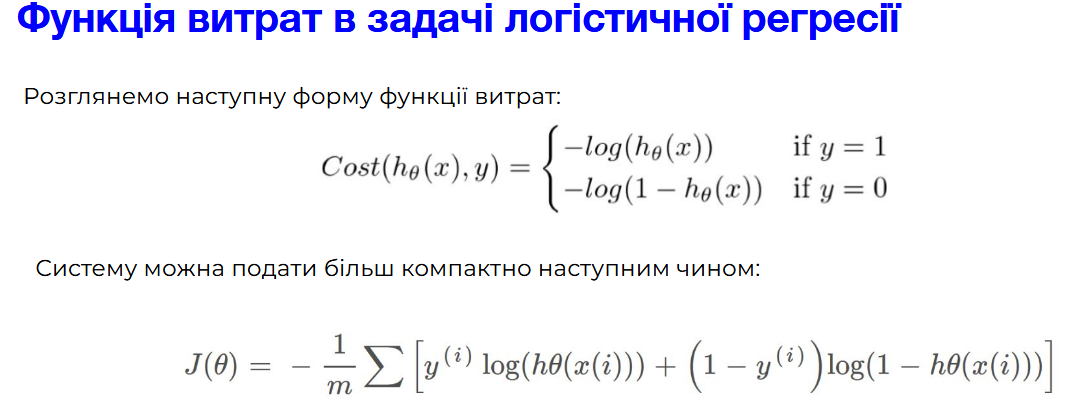

**Як обробляється тета для full_batch_gradient_descent:**

Ініціалізація: Рядок theta = np.zeros(X.shape[1]) створює новий тета-вектор, заповнюючи його нулями. Це ваша початкова точка.

Перша ітерація циклу for:

full_batch_gradient_descent викликає compute_gradient та передає йому поточний тета-вектор.

Усередині compute_gradient ця тета використовується для обчислення градієнта.

compute_gradient завершує свою роботу та повертає значення градієнта.

Оновлення тети: Рядок theta = theta - lr * gradient оновлює початковий тета-вектор у full_batch_gradient_descent, використовуючи повернутий градієнт.

Наступна ітерація циклу for: Цикл повторюється, але цього разу він передає щойно оновлену тету до compute_gradient.

Цей процес триває протягом заданої кількості епох. compute_gradient завжди використовує тету, яка була передана йому з функції full_batch_gradient_descent, яка оновлюється на кожному кроці.

#### Завдання 5. Обчислення точності моделі

1. Напишіть функцію `predict_proba(theta, X)`, яка використовує знайдені параметри $\theta$ для обчислення ймовірностей належності поточного прикладу з даних до класу $y=1$ на основі значень $\sigma(\theta^T x)$.

2. Напишіть функцію `predict(theta, X, threshold=0.5)`, яка обчислює клас з передбаченої імовірності належності екземпляра до класу 1 з порогом 0.5. Тобто якщо ймовірність менше 0.5, то передбачаємо клас 0, інакше клас 1.

3. Напишіть функцію `accuracy(y_true, y_pred)`, яка обчислює точність моделі, визначивши частку правильно передбачених класів.

  Формула метрики Accuracy:
  $$
  \text{Accuracy} = \frac{\sum_{i=1}^{m} I(\hat{{y}^{(i)}} = y^{(i)})}{m}
  $$

  де $\hat{{y}^{(i)}}$ - передбачене значення класу, $I$ - індикаторна функція (яка дорівнює 1, якщо умова виконується, і 0 - якщо ні), $m$ - кількість прикладів.

4. Обчисліть з використанням даних в завданні 4 $X$, $y$ та обчислених коефіцієнтах $\theta$ та виведіть на екран:
  - передбачені моделлю імовірності належності кожного з екземплярів в матриці `X` до класу 1
  - класи кожного екземпляра з матриці `X`
  - точність моделі.

**1. Рішення:**

In [36]:
# аналогічно, як у Завданні 2
def predict_proba(theta_learned, X):
  return  1 / (1 + np.exp(-np.dot(theta_learned, X.T)))
print(predict_proba(theta_learned, X))


[0.77966809 0.25617965 0.42815828 0.61944235]


In [37]:
def predict_proba(theta, X):
    return 1 / (1 + np.exp(-(X @ theta)))
print(predict_proba(theta_learned, X))

[0.77966809 0.25617965 0.42815828 0.61944235]


**2. Рішення:**

In [38]:
def predict(theta, X, threshold=0.5):
  probabilities = predict_proba(theta_learned, X) #ймовірність
  predictions = np.where(probabilities >= threshold, 1, 0) #передбачення класу
  return predictions
print(predict_proba(theta_learned, X), predict(theta_learned, X, threshold=0.5))


[0.77966809 0.25617965 0.42815828 0.61944235] [1 0 0 1]


**3. Рішення:**

In [32]:
def accuracy(y_true, y_pred):
  return (y_true == y_pred).sum() / len(y_true)
y_true = y
theta_learned, errors_list = full_batch_gradient_descent(X, y) #з 4 завдання
y_pred = predict(theta_learned, X)
acc = accuracy(y, y_pred)
print(f"Точність моделі: {acc}")


Точність моделі: 0.5


**4. Рішення:**

In [33]:
# 1. Передбаченні ймовірності
probabilities = hypothesis(theta_learned, X)
print(f"Предсказанные вероятности: {probabilities}")

# 2. Передбачені класи
y_pred = predict(theta_learned, X)
print(f"Предсказанные классы: {y_pred}")

# 3. Точність моделі
model_accuracy = accuracy(y, y_pred)
print(f"Точность модели: {model_accuracy}")

Предсказанные вероятности: [0.77966809 0.25617965 0.42815828 0.61944235]
Предсказанные классы: [1 0 0 1]
Точность модели: 0.5
